# Badhan — Data Quality, EDA & Preprocessing

**Assigned contribution:** dataset preparation, quality analysis, exploratory data analysis,
stratified splitting, preprocessing comparison and preprocessing ablation study.

This notebook contains the full data-analysis foundation required by the later modelling stages.


# CSE440: Natural Language Processing II — Lab Project
## Multi-Class Cyberbullying Type Classification from English Tweets

**Task:** Predict one of six cyberbullying categories from an English tweet.

**Target labels:** `age`, `ethnicity`, `gender`, `not_cyberbullying`, `other_cyberbullying`, `religion`.

This notebook follows the required end-to-end workflow: dataset inspection, data-quality analysis, EDA, preprocessing comparison, reproducible train/validation/test splitting, TF-IDF and Word2Vec representations, manual hyperparameter tuning, all required machine-learning and neural-network models, BERT Base fine-tuning, full test evaluation, confusion matrices, consolidated results and exportable experiment tables.



## 1. Project Requirements Checklist

| Requirement | Implementation in this notebook |
|---|---|
| English textual dataset | `cyberbullying_tweets.csv` |
| At least 4 classes | 6 classes |
| At least 10,000 samples | 47,692 raw samples; 44,378 after conflict/duplicate cleanup |
| Data statistics and EDA | Missing values, duplicates, conflicting labels, class distribution, length statistics, word cloud and frequent words |
| Preprocessing comparison | Four lab-based preprocessing strategies compared on validation Macro-F1 |
| Train/validation/test split | Stratified 70% / 15% / 15%, `random_state=42` |
| At least two representations | TF-IDF and Word2Vec |
| Required ML models | Random Forest, Logistic Regression, Multinomial Naive Bayes |
| Required NN models | SimpleRNN, GRU, LSTM, Bidirectional SimpleRNN, Bidirectional GRU, Bidirectional LSTM, BERT Base |
| Manual tuning | At least 3 explicit configurations for every required model |
| Test metrics | Accuracy, Macro-F1, confusion matrix and full classification report |
| Final comparison | Consolidated table, plots, best/worst model and tuning table |

2. Dataset Upload

In [3]:
from google.colab import files

uploaded = files.upload()

!pip -q install gensim datasets transformers accelerate
!unzip -o "/content/archive (4).zip" -d "/content/"

print("Environment setup completed and dataset archive extracted.")

Saving cyberbullying_tweets.csv to cyberbullying_tweets (1).csv
unzip:  cannot find or open /content/archive (4).zip, /content/archive (4).zip.zip or /content/archive (4).zip.ZIP.
Environment setup completed and dataset archive extracted.


## 3. Imports and Reproducibility



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
import tensorflow as tf
import torch

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.probability import FreqDist
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

physical_gpus = tf.config.list_physical_devices('GPU')
for gpu in physical_gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass

print("Imports completed.")
print("TensorFlow GPU devices:", physical_gpus)
print("PyTorch CUDA available:", torch.cuda.is_available())

Imports completed.
TensorFlow GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch CUDA available: True


## 4. Problem Definition

Cyberbullying is not a single homogeneous category. A content-moderation system may need to distinguish attacks based on **age, ethnicity, gender and religion**, while also separating **other cyberbullying** from **non-cyberbullying** content. This is therefore a six-class text classification problem rather than a binary toxicity or sentiment task.

The central research questions are:
1. How much do different lab-based preprocessing strategies affect validation performance?
2. How does sparse TF-IDF compare with distributed Word2Vec representations?
3. How do classical ML models compare with recurrent neural networks and BERT Base?
4. Which model provides the strongest Macro-F1 across all six classes?

## 5. Dataset Loading and Initial Inspection

The supplied CSV contains two columns: tweet text and the cyberbullying class label.

In [4]:
DATA_PATH = "/content/cyberbullying_tweets.csv"
df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Number of classes:", df["cyberbullying_type"].nunique())
df.head()

Raw dataset shape: (47692, 2)
Columns: ['tweet_text', 'cyberbullying_type']
Number of classes: 6


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


## 6. Data Quality Analysis

The project requires missing-value and duplicate analysis. In addition to exact duplicate rows, this dataset contains repeated tweet texts. Some repeated texts are associated with more than one label, which would create contradictory supervision and possible leakage if the same text appears in different splits.

The cleanup policy is:
1. Remove rows with missing text or missing labels.
2. Identify tweet texts assigned to multiple different labels and remove all rows for those contradictory texts.
3. Remove remaining duplicate tweet texts with the same label.
4. Perform the train/validation/test split only after this cleanup.

In [5]:
missing_summary = df.isna().sum()
exact_duplicate_rows = df.duplicated().sum()
unique_texts = df["tweet_text"].nunique()
repeated_text_extra_rows = len(df) - unique_texts

label_counts_per_text = df.groupby("tweet_text")["cyberbullying_type"].nunique()
conflicting_texts = label_counts_per_text[label_counts_per_text > 1].index
conflicting_rows = df[df["tweet_text"].isin(conflicting_texts)].shape[0]

quality_summary = pd.DataFrame({
    "Measure": [
        "Raw rows",
        "Missing tweet_text",
        "Missing cyberbullying_type",
        "Exact duplicate rows",
        "Extra rows caused by repeated tweet text",
        "Tweet texts with conflicting labels",
        "Rows involved in conflicting labels"
    ],
    "Value": [
        len(df),
        missing_summary["tweet_text"],
        missing_summary["cyberbullying_type"],
        exact_duplicate_rows,
        repeated_text_extra_rows,
        len(conflicting_texts),
        conflicting_rows
    ]
})
quality_summary

,Measure,Value
0,Raw rows,47692
1,Missing tweet_text,0
2,Missing cyberbullying_type,0
3,Exact duplicate rows,36
4,Extra rows caused by repeated tweet text,1675
5,Tweet texts with conflicting labels,1639
6,Rows involved in conflicting labels,3278


In [6]:
df = df.dropna(subset=["tweet_text", "cyberbullying_type"]).copy()

label_counts_per_text = df.groupby("tweet_text")["cyberbullying_type"].nunique()
conflicting_texts = label_counts_per_text[label_counts_per_text > 1].index

df = df[~df["tweet_text"].isin(conflicting_texts)].copy()
df = df.drop_duplicates(subset=["tweet_text"]).reset_index(drop=True)

print("Dataset shape after quality cleanup:", df.shape)
print("Remaining duplicate tweet texts:", df["tweet_text"].duplicated().sum())
print("Remaining missing values:")
print(df.isna().sum())

Dataset shape after quality cleanup: (44378, 2)
Remaining duplicate tweet texts: 0
Remaining missing values:
tweet_text            0
cyberbullying_type    0
dtype: int64


## 7. Exploratory Data Analysis

### 7.1 Class Distribution
A balanced target distribution is preferable for multi-class evaluation. We report both raw counts and percentages and calculate the largest-to-smallest class ratio.

In [7]:
class_counts = df["cyberbullying_type"].value_counts()
class_percent = (class_counts / len(df) * 100).round(2)
class_distribution = pd.DataFrame({"Count": class_counts, "Percentage": class_percent})
imbalance_ratio = class_counts.max() / class_counts.min()

print("Largest-to-smallest class ratio:", round(imbalance_ratio, 3))
class_distribution

Largest-to-smallest class ratio: 1.28


,Count,Percentage
cyberbullying_type,,
age,7992,18.01
religion,7991,18.01
ethnicity,7952,17.92
gender,7772,17.51
not_cyberbullying,6428,14.48
other_cyberbullying,6243,14.07


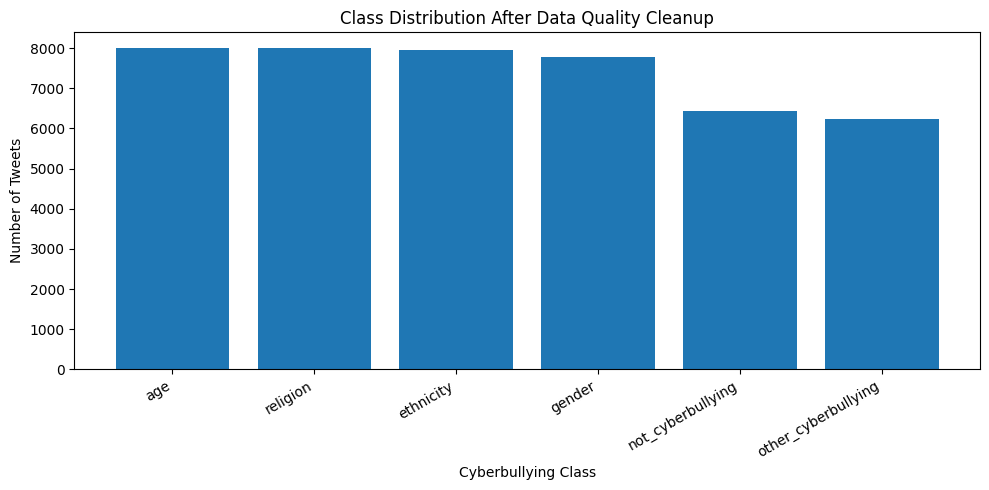

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(class_counts.index, class_counts.values)
plt.title("Class Distribution After Data Quality Cleanup")
plt.xlabel("Cyberbullying Class")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 7.2 Tweet Length Statistics
Tweet length is measured in both characters and whitespace-separated words. These statistics help justify the sequence length used later for recurrent models and BERT tokenization.

In [9]:
df["char_count"] = df["tweet_text"].astype(str).apply(len)
df["word_count"] = df["tweet_text"].astype(str).apply(lambda text: len(text.split()))

length_statistics = df[["char_count", "word_count"]].describe().round(2)
length_statistics

,char_count,word_count
count,44378.00,44378.00
mean,140.09,24.44
std,86.48,15.63
min,1.00,1.00
25%,81.00,14.00
50%,127.00,21.00
75%,194.00,34.00
max,5018.00,790.00


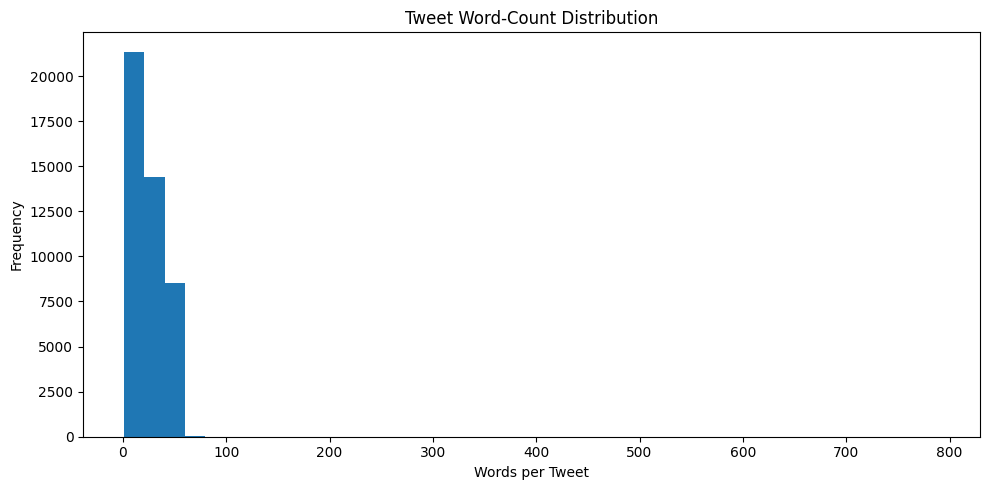

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(df["word_count"], bins=40)
plt.title("Tweet Word-Count Distribution")
plt.xlabel("Words per Tweet")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 7.3 Overall Word Cloud and Frequent Words
The word cloud follows the workflow: tokenize, keep alphabetic tokens, create a frequency distribution and render a word cloud from those frequencies.

In [11]:
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

all_text = " ".join(df["tweet_text"].astype(str).tolist())
tokens = word_tokenize(all_text.lower())
filtered_tokens = []
for word in tokens:
    if word.isalpha():
        filtered_tokens.append(word)

word_frequency = FreqDist(filtered_tokens)
print("Top 20 alphabetic tokens:")
print(word_frequency.most_common(20))

Top 20 alphabetic tokens:
[('the', 29868), ('i', 24187), ('a', 23867), ('to', 22349), ('and', 21171), ('you', 19943), ('of', 14818), ('in', 14513), ('is', 13937), ('that', 12363), ('it', 11180), ('are', 9198), ('school', 8770), ('for', 8332), ('me', 7551), ('not', 7251), ('was', 6582), ('my', 6504), ('this', 6282), ('they', 6264)]


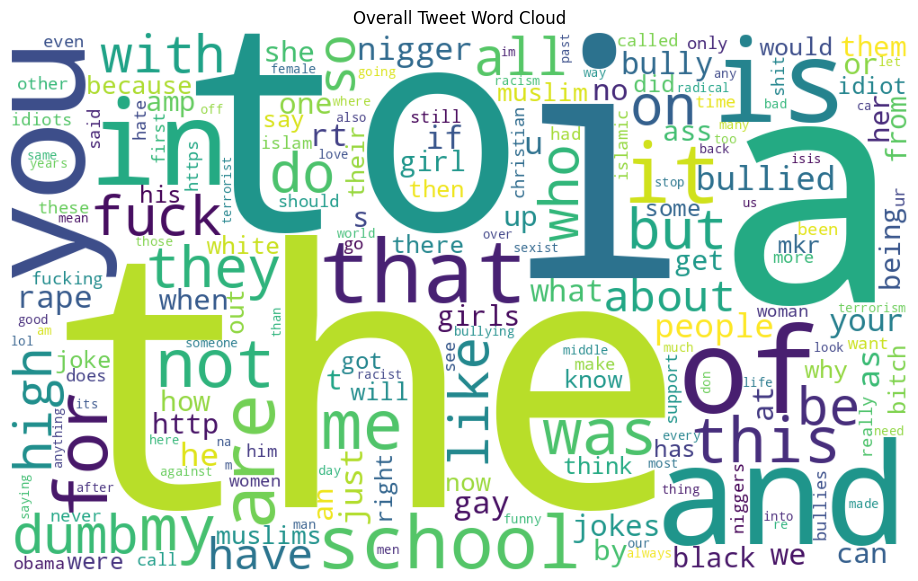

In [12]:
word_cloud = WordCloud(width=1000, height=600, background_color="white", max_words=200)
cloud = word_cloud.generate_from_frequencies(word_frequency)

plt.figure(figsize=(12, 7))
plt.imshow(cloud)
plt.axis("off")
plt.title("Overall Tweet Word Cloud")
plt.show()

### 7.4 Class-Specific Word Clouds

These plots help reveal which lexical cues are distinctive within each label and later support interpretation of class-specific confusion patterns.

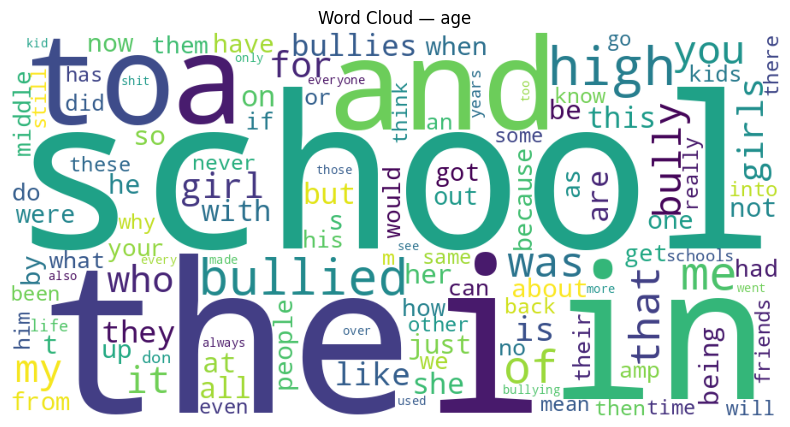

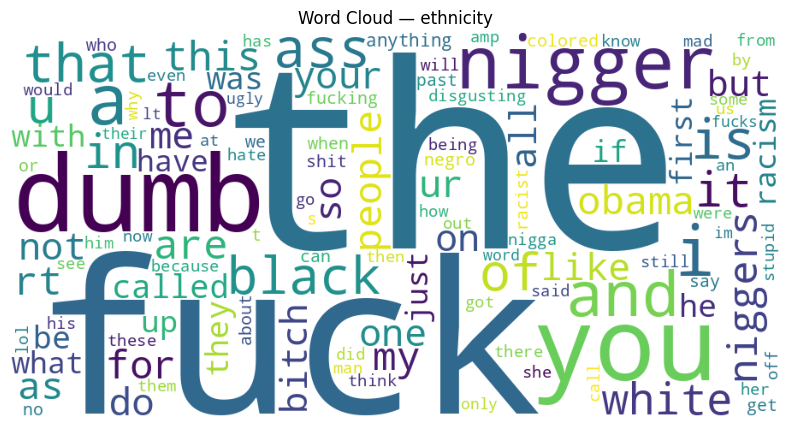

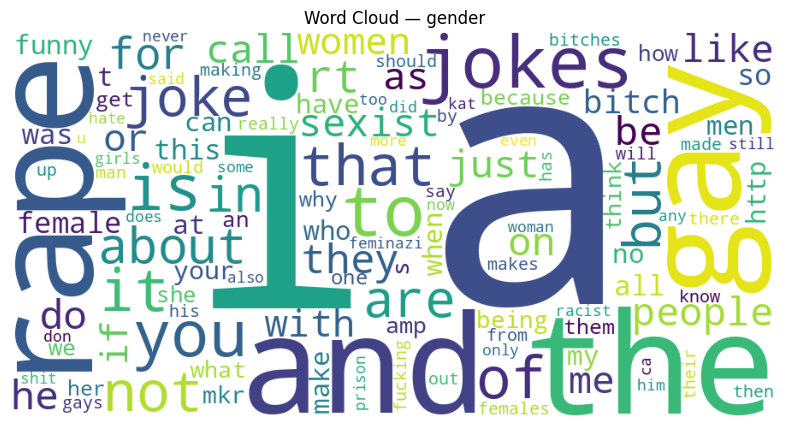

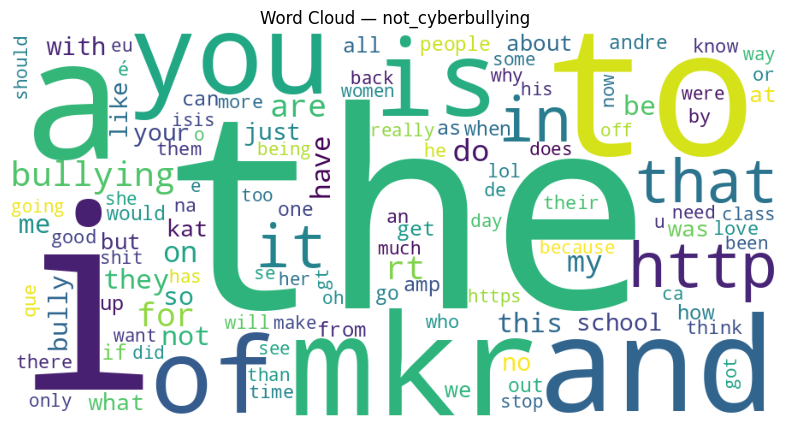

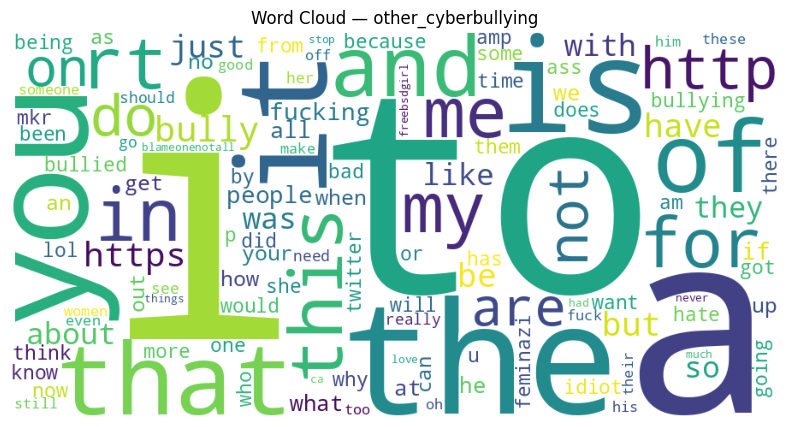

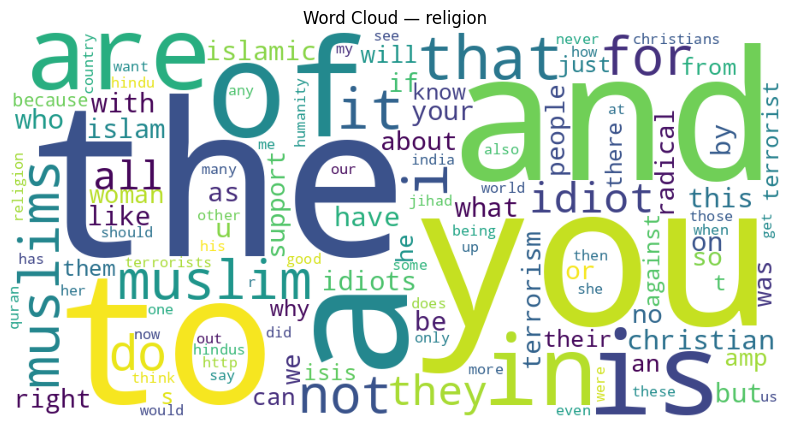

In [13]:
for class_name in sorted(df["cyberbullying_type"].unique()):
    class_text = " ".join(df.loc[df["cyberbullying_type"] == class_name, "tweet_text"].astype(str).tolist())
    class_tokens = word_tokenize(class_text.lower())
    class_filtered_tokens = []
    for word in class_tokens:
        if word.isalpha():
            class_filtered_tokens.append(word)

    class_frequency = FreqDist(class_filtered_tokens)
    class_word_cloud = WordCloud(width=900, height=450, background_color="white", max_words=120)
    class_cloud = class_word_cloud.generate_from_frequencies(class_frequency)

    plt.figure(figsize=(10, 5))
    plt.imshow(class_cloud)
    plt.axis("off")
    plt.title("Word Cloud — " + class_name)
    plt.show()

## 8. Label Encoding and Stratified Train/Validation/Test Split

The cleaned dataset is split **70% / 15% / 15%**. Stratification preserves the six-class distribution in every partition and `random_state=42` makes the split reproducible.

In [14]:
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["cyberbullying_type"])

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=df["label"]
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
validation_df = validation_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Class mapping:", dict(enumerate(label_encoder.classes_)))
print("Train shape:", train_df.shape)
print("Validation shape:", validation_df.shape)
print("Test shape:", test_df.shape)

Class mapping: {0: 'age', 1: 'ethnicity', 2: 'gender', 3: 'not_cyberbullying', 4: 'other_cyberbullying', 5: 'religion'}
Train shape: (31064, 5)
Validation shape: (6657, 5)
Test shape: (6657, 5)


In [15]:
split_distribution = pd.DataFrame({
    "Train": train_df["cyberbullying_type"].value_counts(normalize=True).sort_index(),
    "Validation": validation_df["cyberbullying_type"].value_counts(normalize=True).sort_index(),
    "Test": test_df["cyberbullying_type"].value_counts(normalize=True).sort_index()
}).round(4)

split_distribution

,Train,Validation,Test
cyberbullying_type,,,
age,0.1801,0.1801,0.1801
ethnicity,0.1792,0.1792,0.1792
gender,0.1751,0.1752,0.1752
not_cyberbullying,0.1449,0.1448,0.1448
other_cyberbullying,0.1407,0.1406,0.1408
religion,0.1801,0.1801,0.1800


## 9. Preprocessing Strategies

Four preprocessing strategies are built from Lab 1 operations. Their effect is tested with the same TF-IDF + Logistic Regression validation baseline so that preprocessing is selected empirically instead of by assumption.

- **Lowercase only:** retains all symbols, hashtags and punctuation after lowercasing.
- **Alphabetic tokens:** lowercases, tokenizes and retains alphabetic tokens only.
- **Stopword + stemming:** adds English stopword removal and Porter stemming.
- **Stopword + lemmatization:** adds English stopword removal and WordNet lemmatization.

In [16]:
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()


def preprocess_lowercase(text):
    return str(text).lower()


def preprocess_alpha(text):
    words = word_tokenize(str(text).lower())
    filtered_words = []
    for word in words:
        if word.isalpha():
            filtered_words.append(word)
    return " ".join(filtered_words)


def preprocess_stem(text):
    words = word_tokenize(str(text).lower())
    filtered_words = []
    for word in words:
        if word.isalpha() and word not in stop_words:
            filtered_words.append(stemmer.stem(word))
    return " ".join(filtered_words)


def preprocess_lemma(text):
    words = word_tokenize(str(text).lower())
    filtered_words = []
    for word in words:
        if word.isalpha() and word not in stop_words:
            filtered_words.append(lemmatizer.lemmatize(word, pos="v"))
    return " ".join(filtered_words)


preprocessing_functions = {
    "Lowercase only": preprocess_lowercase,
    "Alphabetic tokens": preprocess_alpha,
    "Stopword + stemming": preprocess_stem,
    "Stopword + lemmatization": preprocess_lemma
}

print("Preprocessing functions defined:", list(preprocessing_functions.keys()))

Preprocessing functions defined: ['Lowercase only', 'Alphabetic tokens', 'Stopword + stemming', 'Stopword + lemmatization']


In [17]:
sample_text = train_df.loc[0, "tweet_text"]
print("Original:", sample_text)
for name, function in preprocessing_functions.items():
    print("\n" + name + ":")
    print(function(sample_text))

Original: Man this nigger dumb as fuck RT "@Lumkile1st: Lmao. fake weed? "@MyNamezTom: The cops are giving people fake weed then arresting them""

Lowercase only:
man this nigger dumb as fuck rt "@lumkile1st: lmao. fake weed? "@mynameztom: the cops are giving people fake weed then arresting them""

Alphabetic tokens:
man this nigger dumb as fuck rt lmao fake weed mynameztom the cops are giving people fake weed then arresting them

Stopword + stemming:
man nigger dumb fuck rt lmao fake weed mynameztom cop give peopl fake weed arrest

Stopword + lemmatization:
man nigger dumb fuck rt lmao fake weed mynameztom cop give people fake weed arrest


### 9.1 Validation-Based Preprocessing Selection

Each preprocessing strategy is fitted only on the training split through a TF-IDF vectorizer, then evaluated on the validation split using Logistic Regression. The strategy with the highest validation **Macro-F1** is selected for the classical and recurrent-model experiments.

In [18]:
preprocessing_results = []

for name, function in preprocessing_functions.items():
    train_text = train_df["tweet_text"].apply(function)
    validation_text = validation_df["tweet_text"].apply(function)

    preprocessing_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")
    X_train_preprocessing = preprocessing_tfidf.fit_transform(train_text)
    X_validation_preprocessing = preprocessing_tfidf.transform(validation_text)

    preprocessing_model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    preprocessing_model.fit(X_train_preprocessing, train_df["label"])
    validation_prediction = preprocessing_model.predict(X_validation_preprocessing)

    validation_accuracy = accuracy_score(validation_df["label"], validation_prediction)
    validation_f1 = f1_score(validation_df["label"], validation_prediction, average="macro")

    preprocessing_results.append({
        "Preprocessing": name,
        "Validation Accuracy": validation_accuracy,
        "Validation Macro F1": validation_f1
    })

preprocessing_results_df = pd.DataFrame(preprocessing_results).sort_values(
    "Validation Macro F1", ascending=False
).reset_index(drop=True)

preprocessing_results_df

,Preprocessing,Validation Accuracy,Validation Macro F1
0,Lowercase only,0.868259,0.855946
1,Stopword + lemmatization,0.864203,0.851797
2,Stopword + stemming,0.863302,0.850771
3,Alphabetic tokens,0.861499,0.849439


In [19]:
best_preprocessing_name = preprocessing_results_df.loc[0, "Preprocessing"]
best_preprocessing_function = preprocessing_functions[best_preprocessing_name]

train_df["clean_text"] = train_df["tweet_text"].apply(best_preprocessing_function)
validation_df["clean_text"] = validation_df["tweet_text"].apply(best_preprocessing_function)
test_df["clean_text"] = test_df["tweet_text"].apply(best_preprocessing_function)

print("Selected preprocessing strategy:", best_preprocessing_name)
print("Example cleaned tweet:")
print(train_df.loc[0, "clean_text"])

Selected preprocessing strategy: Lowercase only
Example cleaned tweet:
man this nigger dumb as fuck rt "@lumkile1st: lmao. fake weed? "@mynameztom: the cops are giving people fake weed then arresting them""


### 9.2 Ablation Study of Preprocessing Components

To analyze the contribution of individual preprocessing components, a controlled ablation study is conducted using the same TF-IDF representation and Logistic Regression classifier. The preprocessing pipeline is constructed incrementally so that the effect of each additional component can be measured while keeping the classifier and feature-extraction settings fixed.

The evaluated configurations are:

1. **Lowercase only:** serves as the baseline.
2. **+ Alphabetic filtering:** removes non-alphabetic tokens.
3. **+ Stopword removal:** additionally removes common English stopwords.
4. **+ Lemmatization:** additionally reduces words to their normalized lemma forms.

For this ablation experiment, stopword removal is not applied inside the TF-IDF vectorizer because it is treated as an explicit preprocessing component. All configurations are trained only on the training split and evaluated on the validation split using Accuracy and Macro-F1. The change in Macro-F1 between consecutive configurations indicates whether each added preprocessing component improves or reduces classification performance.

,Configuration,Validation Accuracy,Validation Macro F1,Macro F1 Change
0,A0: Lowercase only,0.862851,0.849676,NaN
1,A1: + Alphabetic filtering,0.858795,0.845711,-0.003965
2,A2: + Stopword removal,0.863602,0.851879,0.006168
3,A3: + Lemmatization,0.862851,0.850720,-0.001159


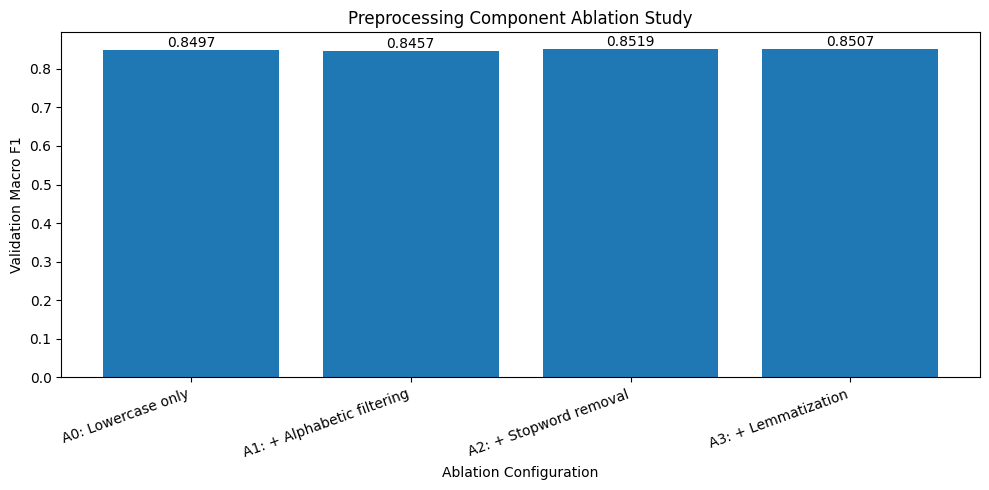

Contribution of each added preprocessing component:
A1: + Alphabetic filtering: -0.0040 Macro-F1 compared with the previous configuration
A2: + Stopword removal: +0.0062 Macro-F1 compared with the previous configuration
A3: + Lemmatization: -0.0012 Macro-F1 compared with the previous configuration


In [20]:
def preprocess_alpha_stopword(text):
    words = word_tokenize(str(text).lower())
    filtered_words = []

    for word in words:
        if word.isalpha() and word not in stop_words:
            filtered_words.append(word)

    return " ".join(filtered_words)


ablation_functions = {
    "A0: Lowercase only": preprocess_lowercase,
    "A1: + Alphabetic filtering": preprocess_alpha,
    "A2: + Stopword removal": preprocess_alpha_stopword,
    "A3: + Lemmatization": preprocess_lemma
}

ablation_results = []

for name, function in ablation_functions.items():
    ablation_train_text = train_df["tweet_text"].apply(function)
    ablation_validation_text = validation_df["tweet_text"].apply(function)

    ablation_tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        stop_words=None
    )

    X_train_ablation = ablation_tfidf.fit_transform(ablation_train_text)
    X_validation_ablation = ablation_tfidf.transform(ablation_validation_text)

    ablation_model = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    )

    ablation_model.fit(X_train_ablation, train_df["label"])
    ablation_prediction = ablation_model.predict(X_validation_ablation)

    ablation_accuracy = accuracy_score(
        validation_df["label"],
        ablation_prediction
    )

    ablation_f1 = f1_score(
        validation_df["label"],
        ablation_prediction,
        average="macro"
    )

    ablation_results.append({
        "Configuration": name,
        "Validation Accuracy": ablation_accuracy,
        "Validation Macro F1": ablation_f1
    })


ablation_results_df = pd.DataFrame(ablation_results)

ablation_results_df["Macro F1 Change"] = (
    ablation_results_df["Validation Macro F1"].diff()
)

display(ablation_results_df)


plt.figure(figsize=(10, 5))

bars = plt.bar(
    ablation_results_df["Configuration"],
    ablation_results_df["Validation Macro F1"]
)

plt.xlabel("Ablation Configuration")
plt.ylabel("Validation Macro F1")
plt.title("Preprocessing Component Ablation Study")
plt.xticks(rotation=20, ha="right")

for bar, score in zip(
    bars,
    ablation_results_df["Validation Macro F1"]
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{score:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


print("Contribution of each added preprocessing component:")

for index in range(1, len(ablation_results_df)):
    component = ablation_results_df.loc[index, "Configuration"]
    change = ablation_results_df.loc[index, "Macro F1 Change"]

    print(
        f"{component}: "
        f"{change:+.4f} Macro-F1 compared with the previous configuration"
    )


ablation_results_df.to_csv(
    "ablation_preprocessing_results.csv",
    index=False
)

## 10. Shared Experiment Tracking and Evaluation Functions

Every required model is tuned with at least three explicit configurations. Validation Accuracy and validation Macro-F1 are recorded for every run. The final test evaluation records Accuracy, Macro-F1, the full classification report and a confusion matrix.

In [22]:
tuning_records = []
final_results = []
confusion_matrices = {}
best_hyperparameters = {}


def record_tuning(model_name, representation, config_id, parameters, validation_accuracy, validation_f1):
    tuning_records.append({
        "Model": model_name,
        "Representation": representation,
        "Config": config_id,
        "Parameters": str(parameters),
        "Validation Accuracy": validation_accuracy,
        "Validation Macro F1": validation_f1
    })


def evaluate_predictions(model_name, representation, y_true, y_pred):
    test_accuracy = accuracy_score(y_true, y_pred)
    test_f1 = f1_score(y_true, y_pred, average="macro")
    test_confusion_matrix = confusion_matrix(y_true, y_pred)

    print("=" * 90)
    print(model_name)
    print("Representation:", representation)
    print("Test Accuracy:", round(test_accuracy, 4))
    print("Test Macro F1:", round(test_f1, 4))
    print("\nFull Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=label_encoder.classes_, zero_division=0))
    print("Confusion Matrix:\n", test_confusion_matrix)

    final_results.append({
        "Model": model_name,
        "Representation": representation,
        "Accuracy": test_accuracy,
        "Macro F1": test_f1
    })
    confusion_matrices[model_name] = test_confusion_matrix

    return test_accuracy, test_f1


print("Experiment tracking and evaluation functions are ready.")

Experiment tracking and evaluation functions are ready.
